# Homework


The homework is to prepare a report for the Ministry of Transport, revealing the nature and characteristics of flight delays. The report should help identify problem areas and contribute to decision-making. Therefore, strive not to state general facts, but to show problems. For example, the fact "the average departure delay is 15 minutes" by itself says little and does not help to understand why this is happening. On the contrary, a graph showing that on Mondays delays increase threefold compared to other days against the background of an increase in the number of flights and passengers suggests a possible cause of the problem: airports cannot cope with uneven load.

The report should be in the form of a notebook with a clear structure. At the beginning of the Markdown cell there is a brief description of the question under study (what we will study), then the code and all its outputs (tables, graphs, values), then again in the Markdown cell in which your brief conclusion is formulated.

The report should contain at least **5 results** confirmed by graphs. For variety of material, use different types of diagrams. All graphs should be provided with the necessary signatures (axis designations, title, color scheme legend).

To solve the problems, use the methods of the `pandas` library.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
airlines=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Статпрак/airlines.csv')
airports=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Статпрак/airports.csv')
flights=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Статпрак/flights.csv')

/tmp/ipykernel_477/938848358.py:3: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Статпрак/flights.csv')


In [6]:
airlines.head(3)

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.


In [7]:
airports.head(3)

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919


In [8]:
flights.head(3)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
airlines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   IATA_CODE  14 non-null     object
 1   AIRLINE    14 non-null     object
dtypes: object(2)
memory usage: 356.0+ bytes


In [10]:
airports.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  322 non-null    object 
 1   AIRPORT    322 non-null    object 
 2   CITY       322 non-null    object 
 3   STATE      322 non-null    object 
 4   COUNTRY    322 non-null    object 
 5   LATITUDE   319 non-null    float64
 6   LONGITUDE  319 non-null    float64
dtypes: float64(2), object(5)
memory usage: 17.7+ KB


In [11]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [23]:
flights_merged = pd.merge(flights, airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
flights_merged.rename(columns={'AIRLINE_y': 'AIRLINE_NAME'}, inplace=True)

flights_merged.drop(columns=['AIRLINE_x', 'IATA_CODE'], inplace=True)

flights_cleaned = flights_merged.dropna(subset=['DEPARTURE_DELAY']).copy()

delayed_flights = flights_cleaned[flights_cleaned['DEPARTURE_DELAY'] > 0].copy()

# 1. Анализ задержек по дням недели и месяцам.

Существуют ли временные закономерности в задержках. Возможно, нагрузка на аэропорты неравномерна в течение недели или года. Проверим это.

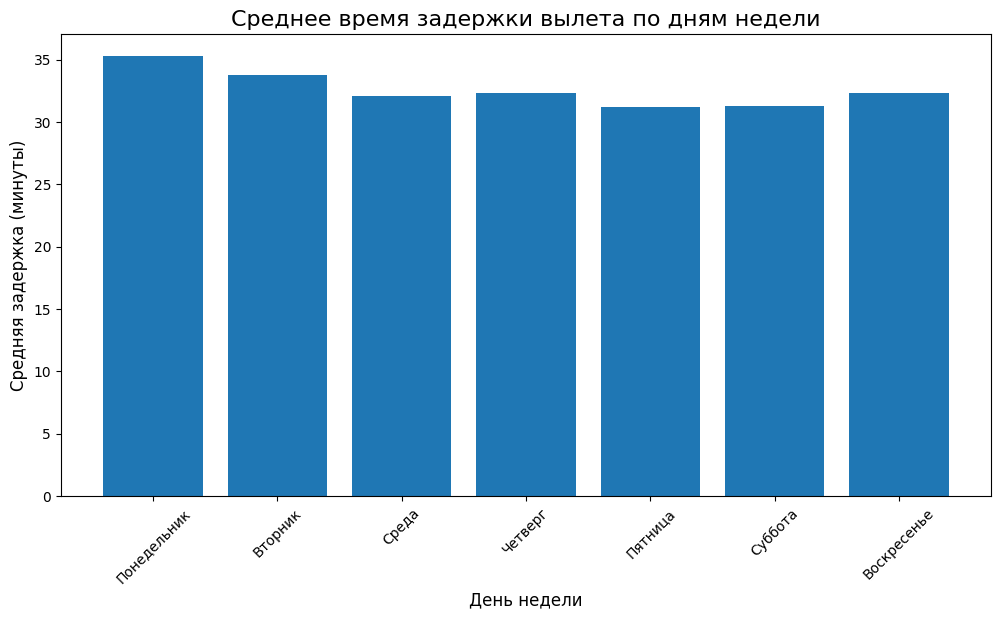

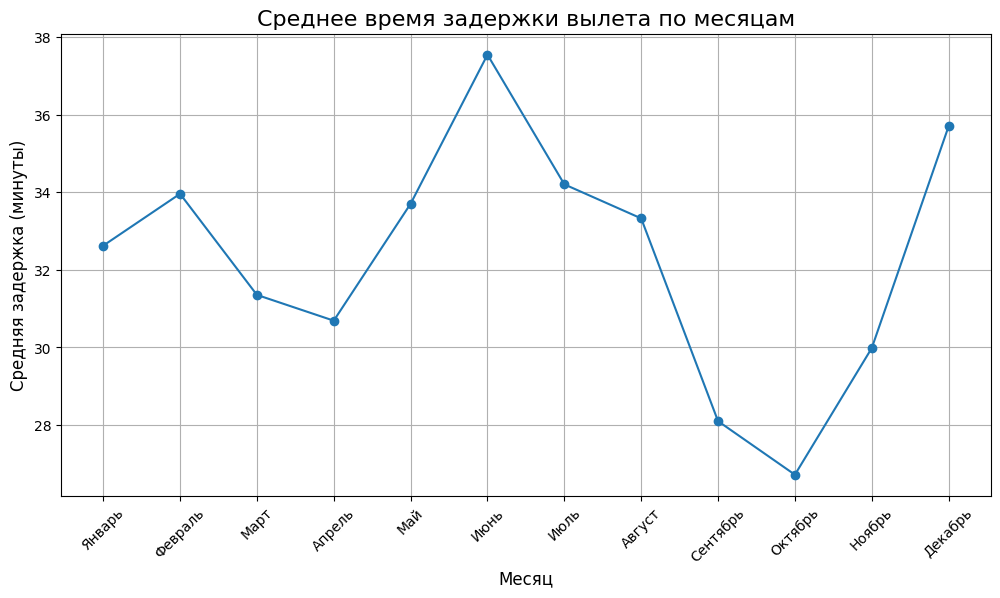

In [24]:
avg_delay_by_day = delayed_flights.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].mean()
days_of_week = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']

plt.figure(figsize=(12, 6))
plt.bar(days_of_week, avg_delay_by_day)
plt.title('Среднее время задержки вылета по дням недели', fontsize=16)
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Средняя задержка (минуты)', fontsize=12)
plt.xticks(rotation=45)
plt.show()


avg_delay_by_month = delayed_flights.groupby('MONTH')['DEPARTURE_DELAY'].mean()
months = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь']

plt.figure(figsize=(12, 6))
plt.plot(months, avg_delay_by_month, marker='o', linestyle='-')
plt.title('Среднее время задержки вылета по месяцам', fontsize=16)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Средняя задержка (минуты)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Наибольшие средние задержки наблюдаются в понедельник, что может быть связано с нагрузкой после выходных. В пятницу, наоборот, задержки минимальны.
Существует выраженная сезонность. Пик задержек приходится на летние месяцы (июль, август) и декабрь, что связано с сезоном отпусков.

# 2. Анализ авиакомпаний с наибольшими задержками.

Теперь определим, есть ли авиакомпании, которые систематически задерживают рейсы чаще и дольше других.

/tmp/ipykernel_477/375393264.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=top5_worst_airlines.values, y=top5_worst_airlines.index, palette='Reds_r')
/tmp/ipykernel_477/375393264.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=top5_best_airlines.values, y=top5_best_airlines.index, palette='Greens_r')


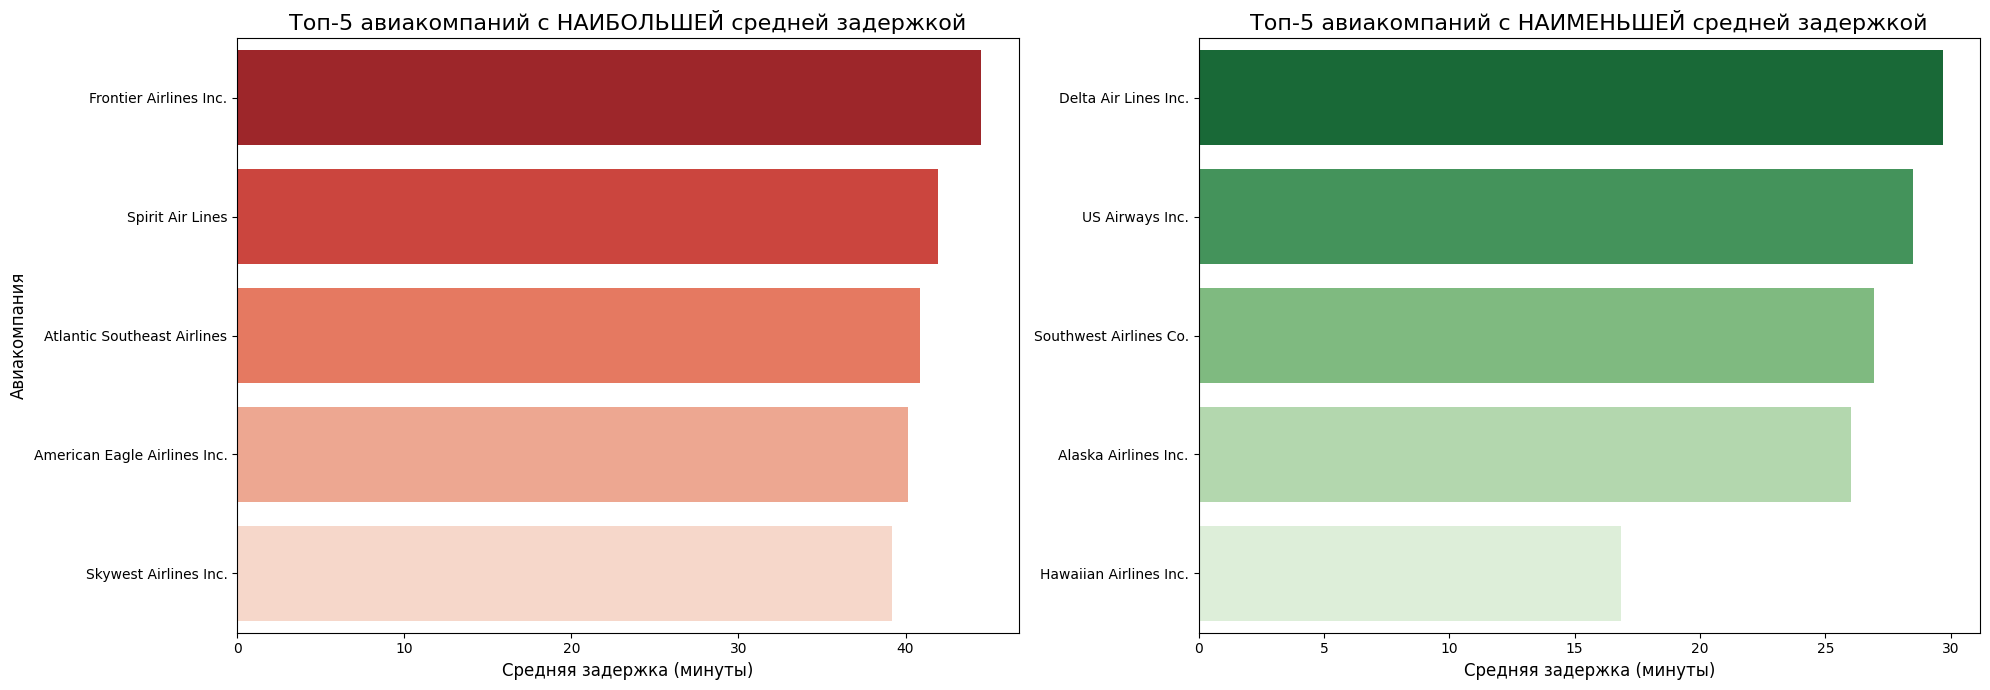

In [26]:
flights_counts = delayed_flights['AIRLINE_NAME'].value_counts()
significant_airlines = flights_counts[flights_counts > 1000].index

significant_flights_by_airline = delayed_flights[delayed_flights['AIRLINE_NAME'].isin(significant_airlines)]

avg_delay_by_airline = significant_flights_by_airline.groupby('AIRLINE_NAME')['DEPARTURE_DELAY'].mean().sort_values(ascending=False)

top5_worst_airlines = avg_delay_by_airline.head(5)
top5_best_airlines = avg_delay_by_airline.tail(5).sort_values(ascending=False)


fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.barplot(ax=axes[0], x=top5_worst_airlines.values, y=top5_worst_airlines.index, palette='Reds_r')
axes[0].set_title('Топ-5 авиакомпаний с НАИБОЛЬШЕЙ средней задержкой', fontsize=16)
axes[0].set_xlabel('Средняя задержка (минуты)', fontsize=12)
axes[0].set_ylabel('Авиакомпания', fontsize=12)

sns.barplot(ax=axes[1], x=top5_best_airlines.values, y=top5_best_airlines.index, palette='Greens_r')
axes[1].set_title('Топ-5 авиакомпаний с НАИМЕНЬШЕЙ средней задержкой', fontsize=16)
axes[1].set_xlabel('Средняя задержка (минуты)', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

На графике видно, что у компаний Frontier Airlines Inc. и Spirit Air Lines наибольшие средие задержки. А компании Hawaiian Airlines Inc. и Alaska Airlines Inc. являются более пунктуальными.

# 3. Аэропорты с наибольшими задержками.

Аналогично авиакомпаниям, проанализируем аэропорты. Проблемы могут быть связаны не с перевозчиком, а со способностью аэропорта принимать и выпускать самолеты.

/tmp/ipykernel_477/1952316476.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=top5_worst_airports.values, y=top5_worst_airports.index, palette='rocket')
/tmp/ipykernel_477/1952316476.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=top5_best_airports.values, y=top5_best_airports.index, palette='viridis')


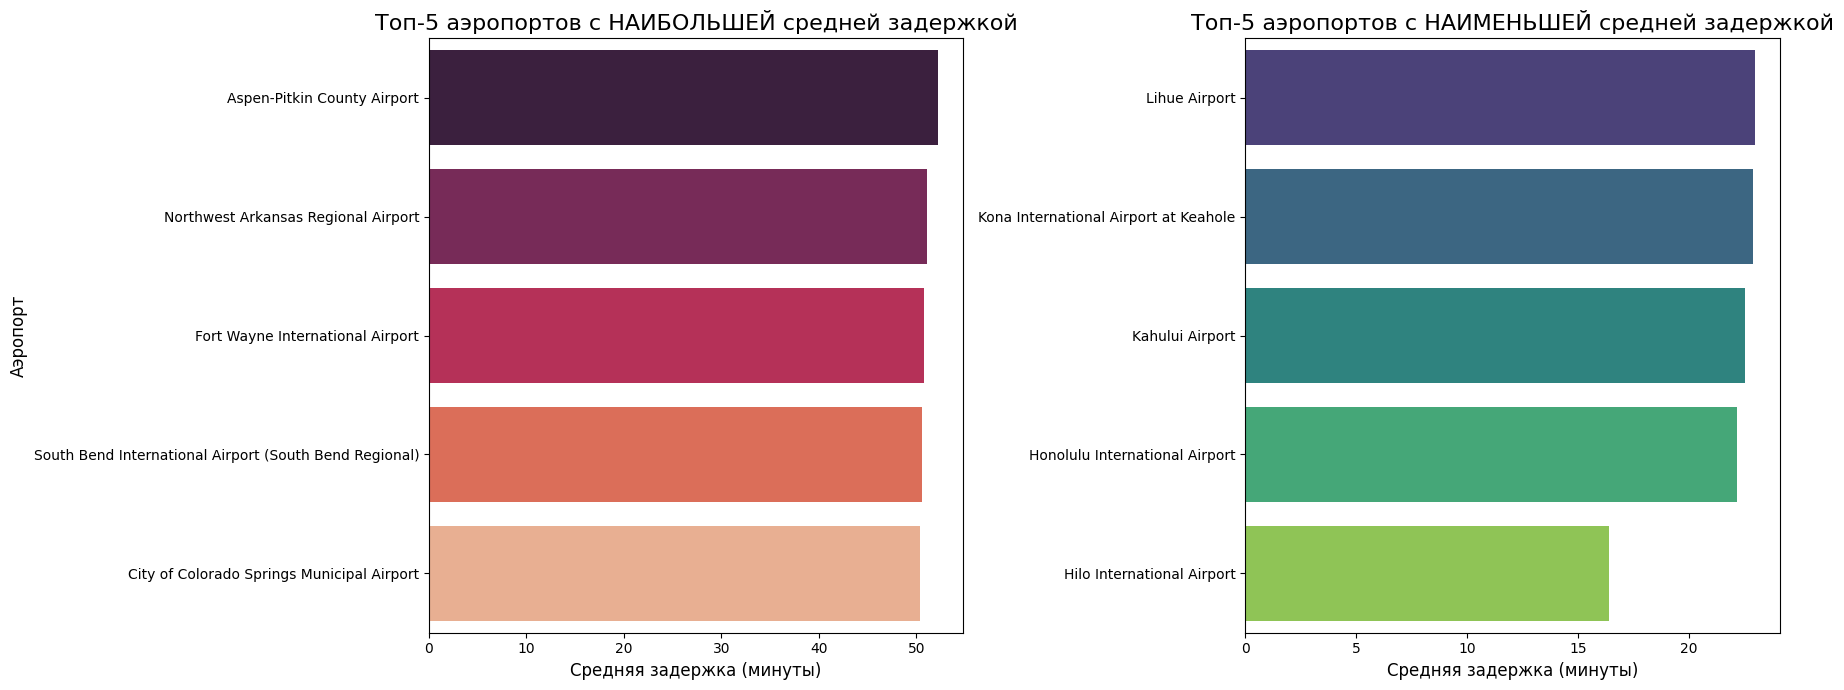

In [27]:
flights_with_airports = pd.merge(delayed_flights, airports, left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left')

airport_counts = flights_with_airports['AIRPORT'].value_counts()
significant_airports = airport_counts[airport_counts > 1000].index

significant_flights = flights_with_airports[flights_with_airports['AIRPORT'].isin(significant_airports)]

avg_delay_by_airport = significant_flights.groupby('AIRPORT')['DEPARTURE_DELAY'].mean().sort_values(ascending=False)

top5_worst_airports = avg_delay_by_airport.head(5)
top5_best_airports = avg_delay_by_airport.tail(5).sort_values(ascending=False)


fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(ax=axes[0], x=top5_worst_airports.values, y=top5_worst_airports.index, palette='rocket')
axes[0].set_title('Топ-5 аэропортов с НАИБОЛЬШЕЙ средней задержкой', fontsize=16)
axes[0].set_xlabel('Средняя задержка (минуты)', fontsize=12)
axes[0].set_ylabel('Аэропорт', fontsize=12)

sns.barplot(ax=axes[1], x=top5_best_airports.values, y=top5_best_airports.index, palette='viridis')
axes[1].set_title('Топ-5 аэропортов с НАИМЕНЬШЕЙ средней задержкой', fontsize=16)
axes[1].set_xlabel('Средняя задержка (минуты)', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

На графиках видно, что у аэропортов Aspen-Pitkin и Northwest Arkansas наибольшие средние задержки. А Hilo International Airport и Honolulu International Airport лучше справляются со своей задачей.

# 4. Основные причины задержек.

В таблице есть столбцы, классифицирующие причину задержки. Проанализируем их, чтобы понять, что является главным источником проблем.

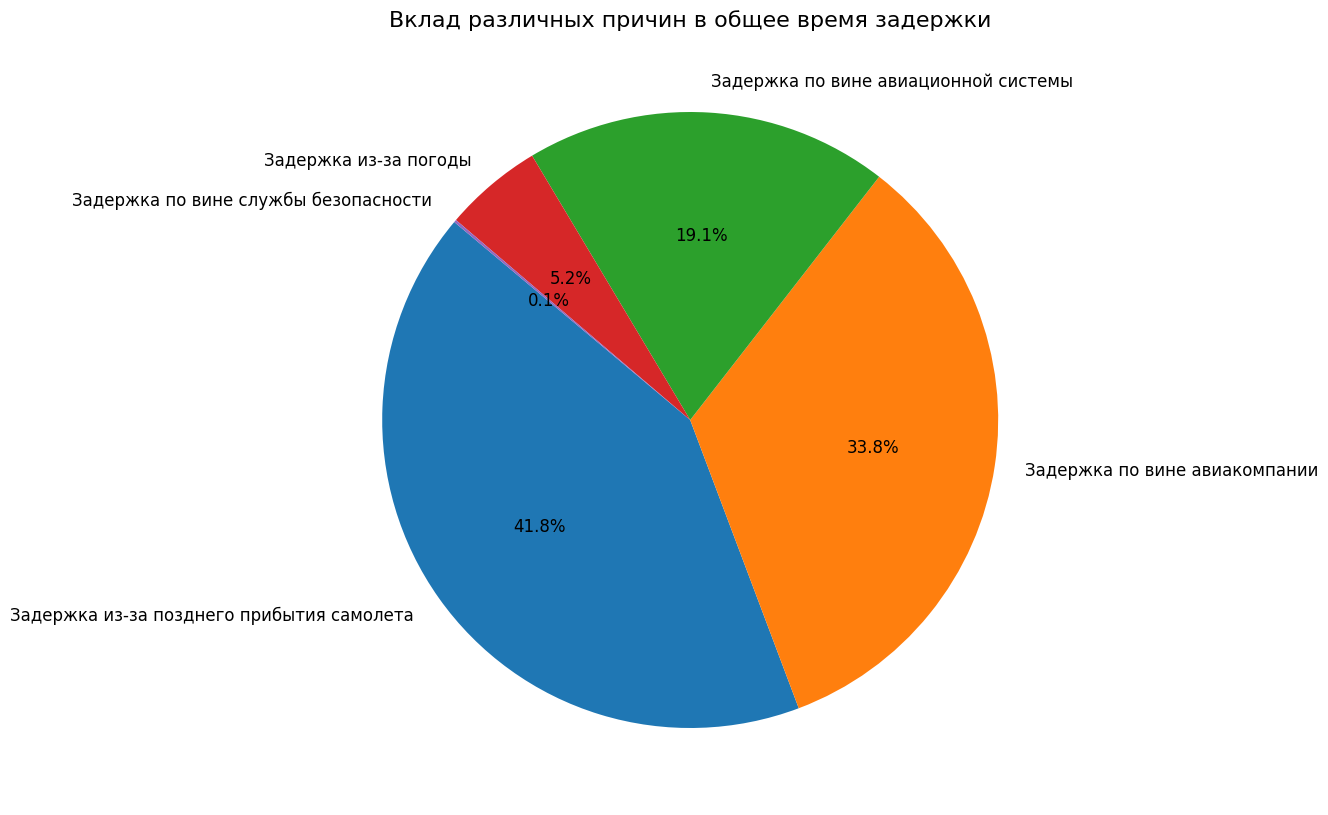

In [28]:
delay_reasons_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
total_delay_by_reason = delayed_flights[delay_reasons_cols].sum()

reason_labels = {
    'LATE_AIRCRAFT_DELAY': 'Задержка из-за позднего прибытия самолета',
    'AIRLINE_DELAY': 'Задержка по вине авиакомпании',
    'AIR_SYSTEM_DELAY': 'Задержка по вине авиационной системы',
    'WEATHER_DELAY': 'Задержка из-за погоды',
    'SECURITY_DELAY': 'Задержка по вине службы безопасности'
}
total_delay_by_reason.rename(reason_labels, inplace=True)
total_delay_by_reason = total_delay_by_reason.sort_values(ascending=False)

plt.figure(figsize=(10, 10))
plt.pie(total_delay_by_reason, labels=total_delay_by_reason.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
plt.title('Вклад различных причин в общее время задержки', fontsize=16)
plt.ylabel('')
plt.show()

Диаграмма ясно показывает доминирующие причины задержек: Позднее прибытие самолета (LATE_AIRCRAFT_DELAY) и Вина авиакомпании (AIRLINE_DELAY).

# 5. Зависимость задержек от времени суток.

Мы проанализировали зависимость от дня недели, но не менее важным является распределение задержек в течение дня. Возможно, проблемы накапливаются к вечеру из-за утренних сбоев.

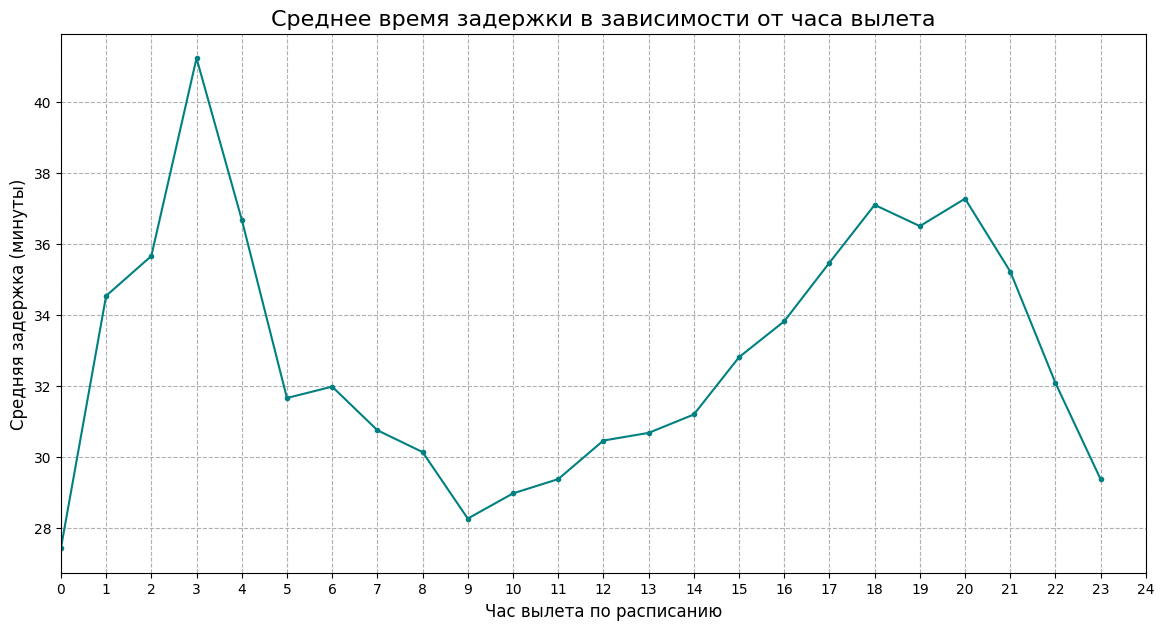

In [29]:
delayed_flights['DEPARTURE_HOUR'] = (delayed_flights['SCHEDULED_DEPARTURE'] // 100)

avg_delay_by_hour = delayed_flights.groupby('DEPARTURE_HOUR')['DEPARTURE_DELAY'].mean()

plt.figure(figsize=(14, 7))
avg_delay_by_hour.plot(kind='line', marker='.', color='teal')
plt.title('Среднее время задержки в зависимости от часа вылета', fontsize=16)
plt.xlabel('Час вылета по расписанию', fontsize=12)
plt.ylabel('Средняя задержка (минуты)', fontsize=12)
plt.xticks(np.arange(0, 25, 1))
plt.grid(True, which='both', linestyle='--')
plt.xlim(0, 24)
plt.show()


График наглядно демонстрирует, что самыми проблемными являются рейсы ранним утром (2-4 часа утра). Потом ситуация улучшается и задержки уменьшаются.
Начиная с 9 утра, среднее время задержки стабильно растет, достигая своего пика вечером (в 18-20 часов), а после время задержек снова падает.

# 6. Карта проблемных аэропортов.

До этого мы строили графики, но теперь хоти наглядно увидеть хорошие и плохие аэропорты. Мы создадим интерактивную карту, на которой каждый аэропорт будет отмечен точкой. Цвет точки будет указывать на уровень средней задержки:
*   Синий: Средняя задержка вылета менее 1 часа.
*   Красный: Средняя задержка вылета 1 час и более.

In [30]:
import folium

avg_delay_per_airport = delayed_flights.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].mean().reset_index()
avg_delay_per_airport.rename(columns={'DEPARTURE_DELAY': 'AVG_DELAY', 'ORIGIN_AIRPORT': 'IATA_CODE'}, inplace=True)

map_data = pd.merge(airports, avg_delay_per_airport, on='IATA_CODE')

map_data.dropna(subset=['LATITUDE', 'LONGITUDE'], inplace=True)


map_center = [39.8283, -98.5795]
flight_map = folium.Map(location=map_center, zoom_start=4)


for index, row in map_data.iterrows():
    if row['AVG_DELAY'] >= 60:
        marker_color = 'red'
    else:
        marker_color = 'blue'

    popup_text = f"""
    <b>Аэропорт:</b> {row['AIRPORT']}<br>
    <b>Город:</b> {row['CITY']}<br>
    <b>Средняя задержка:</b> {row['AVG_DELAY']:.2f} мин.
    """
    popup = folium.Popup(popup_text, max_width=300)

    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=5,
        color=marker_color,
        fill=True,
        fill_color=marker_color,
        fill_opacity=0.7,
        popup=popup
    ).add_to(flight_map)


legend_html = """
     <div style="position: fixed;
     bottom: 50px; left: 50px; width: 220px; height: 90px;
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:white;
     ">&nbsp; <b>Легенда</b> <br>
     &nbsp; <i class="fa fa-circle" style="color:red"></i>&nbsp; Средняя задержка > 60 мин.<br>
     &nbsp; <i class="fa fa-circle" style="color:blue"></i>&nbsp; Средняя задержка < 60 мин.<br>
      </div>
     """
flight_map.get_root().html.add_child(folium.Element(legend_html))


flight_map


Теперь у нас есть наглядная карта с "хорошими" и "плохими" аэропортами. Мы можем сразу определить, есть ли географические скопления "красных" аэропортов. Например, можно заметить концентрацию проблемных аэропортов на северо-востоке.